# Numerical oscillators: Euler, RK2, RK4, and velocity Verlet

**Course Assignments / Quizzes | Mathematical Methods for Physicists II**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Simple harmonic oscillator: Euler and midpoint RK2

For $x''=-cx$ with $c=5$, let $v=x'$, $x(0)=1$, and $v(0)=0$. The exact displacement is $x(t)=\cos(\sqrt{5}t)$.

We compare Euler at $h=0.02,0.08,0.8,1$ and RK2 at $h=0.08,0.05$, including Euler at $h=0.05$.

**Task:** Reproduce all of these step sizes. These original runs all take **200 steps**, so their final times differ; compare solution accuracy at a common time in the next section.


In [2]:
def sho(method, h, steps, c=5, x0=1, v0=0):
    x = x0
    v = v0
    time = [0]
    displacement = [x]
    velocity = [v]

    for i in range(steps):
        if method == 'Euler':
            new_x = x + h*v
            new_v = v - h*c*x
        elif method == 'RK2':
            middle_x = x + h*v/2
            middle_v = v - h*c*x/2
            new_x = x + h*middle_v
            new_v = v - h*c*middle_x
        elif method == 'RK4':
            k1x, k1v = v, -c*x
            k2x = v + h*k1v/2
            k2v = -c*(x + h*k1x/2)
            k3x = v + h*k2v/2
            k3v = -c*(x + h*k2x/2)
            k4x = v + h*k3v
            k4v = -c*(x + h*k3x)
            new_x = x + h*(k1x + 2*k2x + 2*k3x + k4x)/6
            new_v = v + h*(k1v + 2*k2v + 2*k3v + k4v)/6
        else:
            raise ValueError('Choose Euler, RK2, or RK4')
        x, v = new_x, new_v
        time.append((i + 1)*h)
        displacement.append(x)
        velocity.append(v)
    return time, displacement, velocity


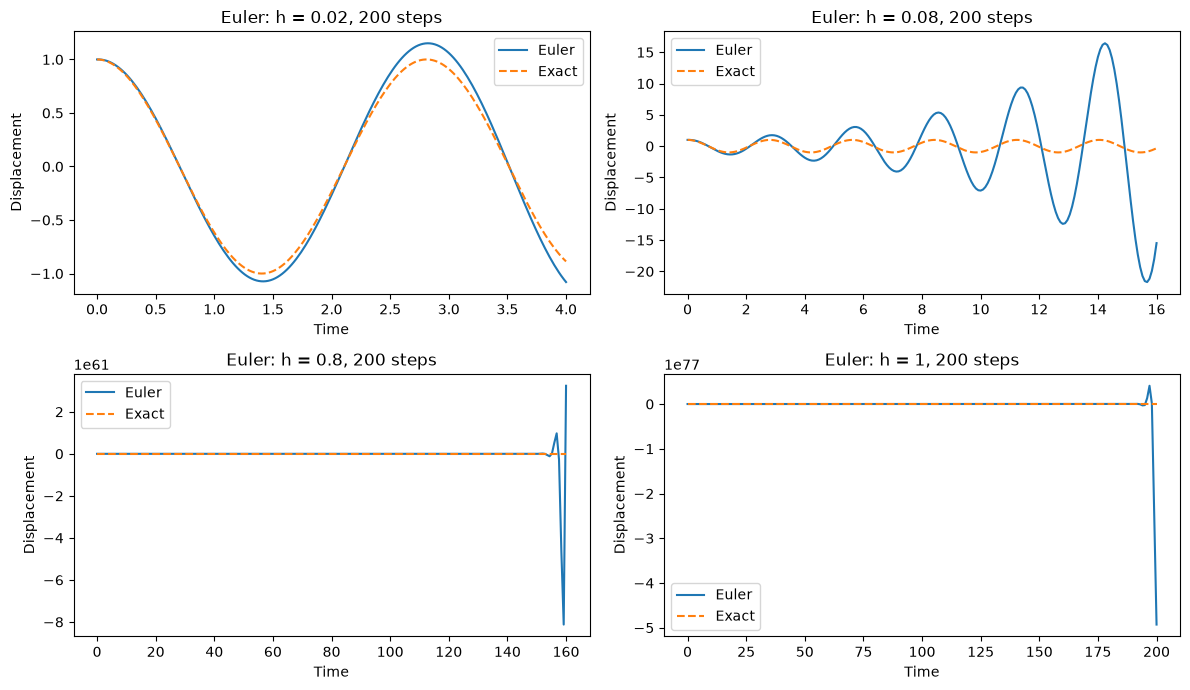

In [3]:
# Compare the Euler method with the exact solution for different step sizes

plt.figure(figsize=(12, 7))
for i, h in enumerate([0.02, 0.08, 0.8, 1]):
    t, x, v = sho('Euler', h, 200)
    plt.subplot(2, 2, i + 1)
    plt.plot(t, x, label='Euler')
    plt.plot(t, np.cos(np.sqrt(5)*np.array(t)), '--', label='Exact')
    plt.title('Euler: h = ' + str(h) + ', 200 steps')
    plt.xlabel('Time')
    plt.ylabel('Displacement')
    plt.legend()
plt.tight_layout()
plt.show()


Large Euler steps make the amplitude grow sharply; on a linear oscillator this is a property of the numerical method, not physical energy gain. The $h=0.8$ and $h=1$ panels have much longer time ranges than the smaller-step panels.

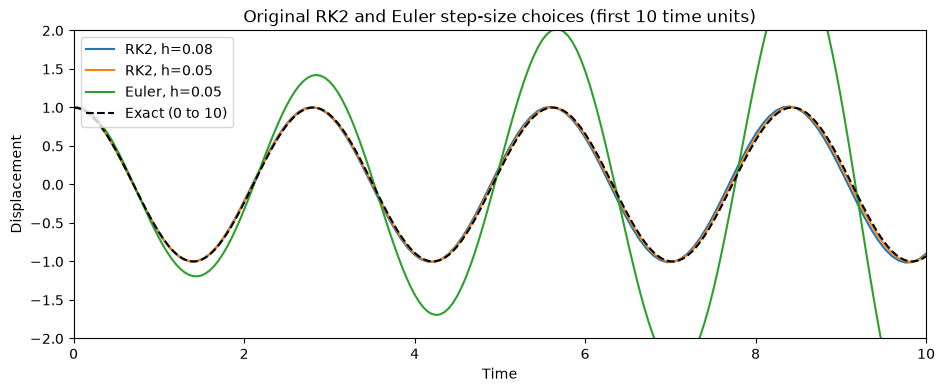

In [4]:
# Compare RK2 with Euler and the exact solution for different step sizes

plt.figure(figsize=(11, 4))
for method, h in [('RK2', 0.08), ('RK2', 0.05), ('Euler', 0.05)]:
    t, x, v = sho(method, h, 200)
    plt.plot(t, x, label=method + ', h=' + str(h))
plt.plot(t, np.cos(np.sqrt(5)*np.array(t)), 'k--', label='Exact (0 to 10)')
plt.xlim(0, 10)
plt.ylim(-2, 2)
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.title('Original RK2 and Euler step-size choices (first 10 time units)')
plt.legend()
plt.show()


## 2. Compare at the same final time

**Task:** Run Euler, midpoint RK2 and RK4 over $0\leq t\leq10$ with the same step size, and check the error at $t=10$. A second comparison tracks $E=(v^2+cx^2)/2$, which should remain constant for the exact oscillator.


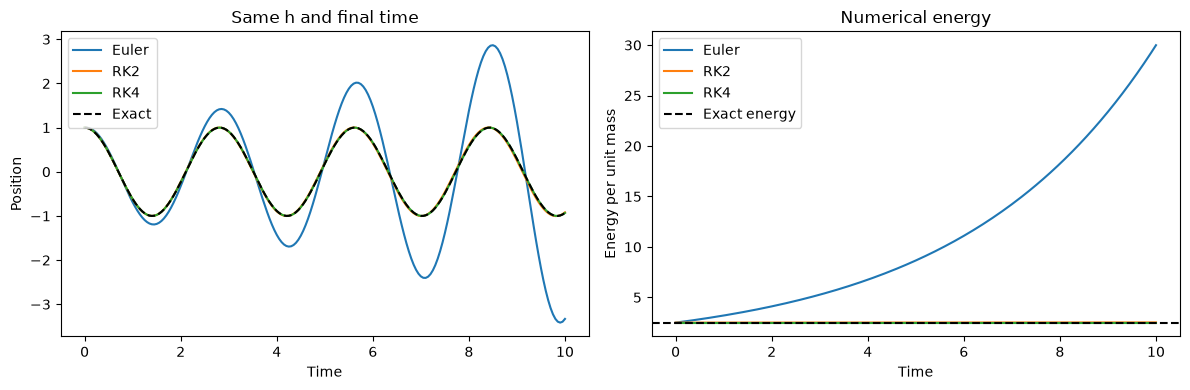

In [5]:
h = 0.05
steps = 200
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for method in ['Euler', 'RK2', 'RK4']:
    t, x, v = sho(method, h, steps)
    plt.plot(t, x, label=method)
plt.plot(t, np.cos(np.sqrt(5)*np.array(t)), 'k--', label='Exact')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Same h and final time')
plt.legend()

plt.subplot(1, 2, 2)
for method in ['Euler', 'RK2', 'RK4']:
    t, x, v = sho(method, h, steps)
    energy = []
    for i in range(len(x)):
        energy.append((v[i]**2 + 5*x[i]**2)/2)
    plt.plot(t, energy, label=method)
plt.axhline(2.5, color='black', linestyle='--', label='Exact energy')
plt.xlabel('Time')
plt.ylabel('Energy per unit mass')
plt.title('Numerical energy')
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
exact_final = np.cos(np.sqrt(5)*10)
step_sizes = [0.2, 0.1, 0.05, 0.025]
for method in ['Euler', 'RK2', 'RK4']:
    print(method)
    for h in step_sizes:
        steps = int(round(10/h))
        t, x, v = sho(method, h, steps)
        print('  h =', h, '  final-position error =', round(abs(x[-1] - exact_final), 8))


Euler
  h = 0.2   final-position error = 53.43226774
  h = 0.1   final-position error = 10.53456754
  h = 0.05   final-position error = 2.39883173
  h = 0.025   final-position error = 0.82314017
RK2
  h = 0.2   final-position error = 0.31366576
  h = 0.1   final-position error = 0.05455477
  h = 0.05   final-position error = 0.01417994
  h = 0.025   final-position error = 0.00381208
RK4
  h = 0.2   final-position error = 4.895e-05
  h = 0.1   final-position error = 8.471e-05
  h = 0.05   final-position error = 7.94e-06
  h = 0.025   final-position error = 5.8e-07


The table shows how the final-position error changes as $h$ is reduced. This is one observable at one final time. The RK4 final-position error need not decrease monotonically for every adjacent pair of step sizes because phase and amplitude errors can partly cancel at that particular time. The full trajectory and energy give additional checks.

## 3. RK4 for nonlinear restoring laws: $n=1,2,3$

We explore $x''=-x^n$ from $x(0)=1$, $v(0)=0$ for $n=1,2,3$. Here each stage evaluates both derivatives at the same intermediate $(x,v)$.

**Task:** Plot displacement and velocity for all three powers. For $n=2$, $-x^2$ always points toward negative $x$; the trajectory can run away instead of oscillating. Stop plotting when $|x|>50$ rather than allowing values to overflow.


n=2 stopped at t = 4.81 when |x| exceeded 50


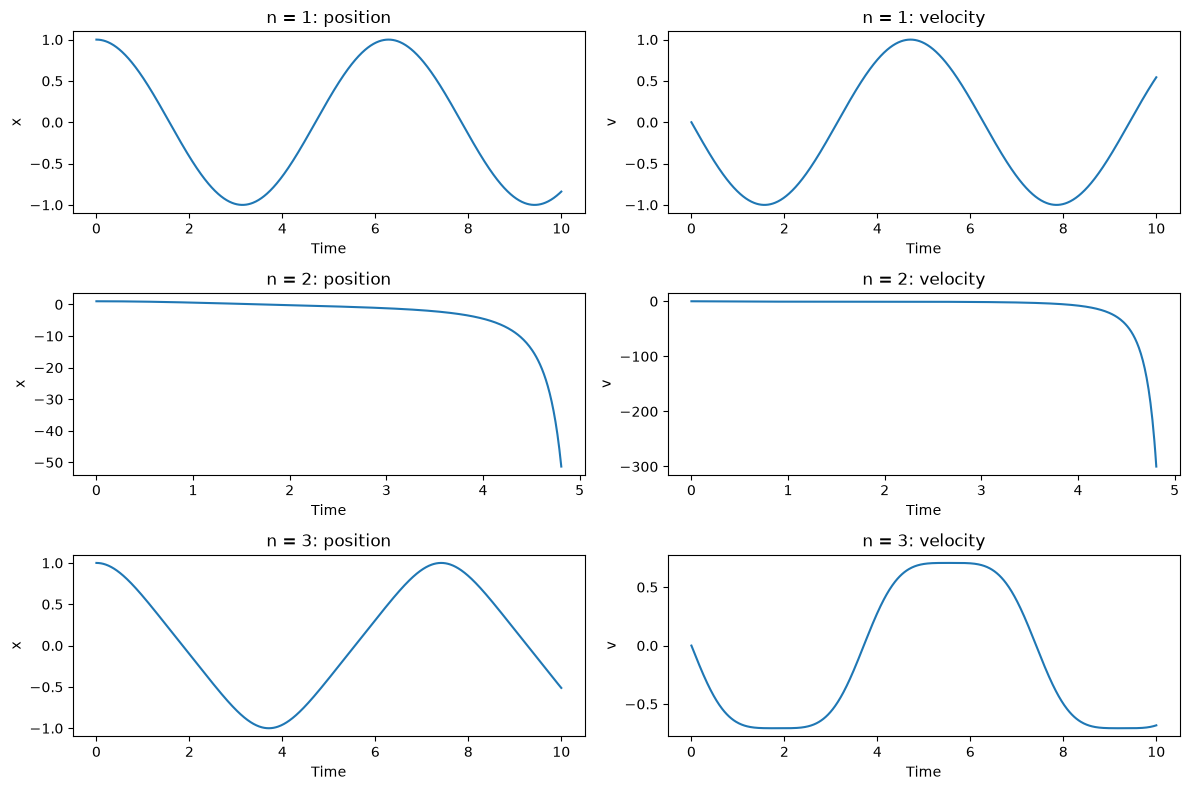

In [7]:
def nonlinear_rk4(n, h=0.01, steps=1000):
    x, v = 1.0, 0.0
    time, positions, velocities = [0.0], [x], [v]
    for i in range(steps):
        k1x, k1v = v, -x**n
        x2 = x + h*k1x/2
        v2 = v + h*k1v/2
        k2x, k2v = v2, -x2**n
        x3 = x + h*k2x/2
        v3 = v + h*k2v/2
        k3x, k3v = v3, -x3**n
        x4 = x + h*k3x
        v4 = v + h*k3v
        k4x, k4v = v4, -x4**n

        x = x + h*(k1x + 2*k2x + 2*k3x + k4x)/6
        v = v + h*(k1v + 2*k2v + 2*k3v + k4v)/6
        time.append((i + 1)*h)
        positions.append(x)
        velocities.append(v)
        if abs(x) > 50:
            break
    return time, positions, velocities

plt.figure(figsize=(12, 8))
for row, n in enumerate([1, 2, 3]):
    t, x, v = nonlinear_rk4(n)
    plt.subplot(3, 2, 2*row + 1)
    plt.plot(t, x)
    plt.title('n = ' + str(n) + ': position')
    plt.xlabel('Time')
    plt.ylabel('x')
    plt.subplot(3, 2, 2*row + 2)
    plt.plot(t, v)
    plt.title('n = ' + str(n) + ': velocity')
    plt.xlabel('Time')
    plt.ylabel('v')
    if n == 2:
        print('n=2 stopped at t =', round(t[-1], 2), 'when |x| exceeded 50')
plt.tight_layout()
plt.show()


The $n=1$ case is harmonic, and $n=3$ has a stable nonlinear restoring force. The $n=2$ case lacks stable restoring behavior for negative $x$. Its early cutoff indicates the model's runaway trajectory, not a failure of RK4 by itself.


## 4. Velocity Verlet and a spring


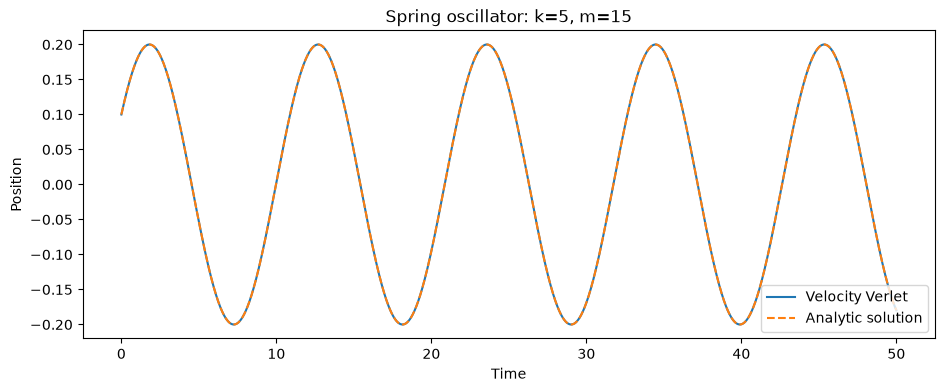

In [8]:
def force_sho(k, eq_x, x):
    return -k*(x - eq_x)

def velocity_verlet(k, m, h, steps, eq_x, x0, v0):
    positions = [x0]
    velocities = [v0]
    forces = [force_sho(k, eq_x, x0)]
    time = [0]
    for i in range(steps):
        new_x = positions[-1] + velocities[-1]*h + forces[-1]*h**2/(2*m)
        new_force = force_sho(k, eq_x, new_x)
        new_v = velocities[-1] + (forces[-1] + new_force)*h/(2*m)
        positions.append(new_x)
        velocities.append(new_v)
        forces.append(new_force)
        time.append((i+1)*h)
    return time, positions, velocities, forces

t, x, v, f = velocity_verlet(5, 15, 0.01, 5000, 0, 0.1, 0.1)
w = np.sqrt(5/15)
exact = 0.1*np.cos(w*np.array(t)) + (0.1/w)*np.sin(w*np.array(t))

plt.figure(figsize=(11, 4))
plt.plot(t, x, label='Velocity Verlet')
plt.plot(t, exact, '--', label='Analytic solution')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Spring oscillator: k=5, m=15')
plt.legend()
plt.show()


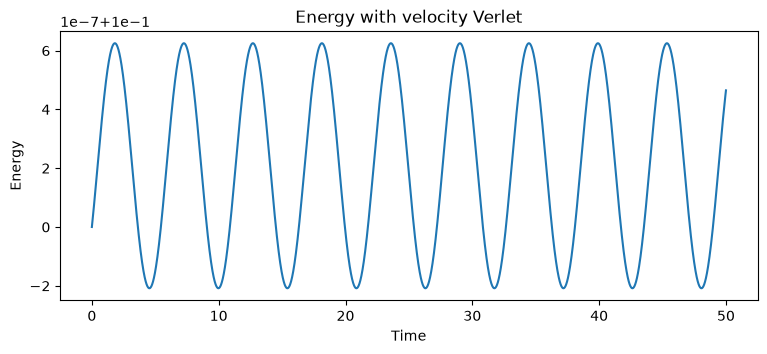

Maximum position difference from analytic curve: 7.4e-06
Relative energy range: 8.33e-06


In [9]:
energy = []
for i in range(len(x)):
    energy.append(15*v[i]**2/2 + 5*x[i]**2/2)
plt.figure(figsize=(9, 3.5))
plt.plot(t, energy)
plt.xlabel('Time')
plt.ylabel('Energy')
plt.title('Energy with velocity Verlet')
plt.show()
print('Maximum position difference from analytic curve:', round(max(abs(np.array(x)-exact)), 8))
print('Relative energy range:', round((max(energy)-min(energy))/energy[0], 8))


## Takeaway

The same physical oscillator exposes different numerical behavior: Euler gains artificial energy, midpoint RK2 is more accurate at the same step size, RK4 follows the analytic trajectory closely, and velocity Verlet keeps the spring energy in a narrow range. The nonlinear $n=2$ example also shows why one must inspect the physical force law before interpreting a numerical plot.

**Provenance:** Original scenarios and parameters: *Homework 04*, *Quiz 04*, and *MD SHM*.


## Equations used in these exercises

### Numerical methods

For a differential equation $\frac{dy}{dt}=f(t,y)$ with time step $h$:

**Forward Euler**
$$
y_{n+1}=y_n+h f(t_n,y_n).
$$

**Midpoint RK2**
$$
k_1=f(t_n,y_n),\qquad
k_2=f\left(t_n+\frac{h}{2},y_n+\frac{h}{2}k_1\right),
$$
$$
y_{n+1}=y_n+h k_2.
$$

**Classical RK4**
$$
k_1=f(t_n,y_n),
$$
$$
k_2=f\left(t_n+\frac{h}{2},y_n+\frac{h}{2}k_1\right),
\qquad
k_3=f\left(t_n+\frac{h}{2},y_n+\frac{h}{2}k_2\right),
$$
$$
k_4=f(t_n+h,y_n+hk_3),
$$
$$
y_{n+1}=y_n+\frac{h}{6}(k_1+2k_2+2k_3+k_4).
$$

Here $y$ can contain more than one variable. For the oscillators and pendulum, we advance position and velocity **together** as $y=(x,v)$ or $y=(\theta,\omega)$.

### Simple harmonic oscillator

The harmonic oscillator satisfies
$$
\frac{dx}{dt}=v,\qquad
\frac{dv}{dt}=-cx,
$$
where $c=k/m$ and the natural angular frequency is $\sqrt{c}$. For $x(0)=1$ and $v(0)=0$, the exact solution is
$$
x(t)=\cos(\sqrt{c}\,t).
$$

Its energy per unit mass is
$$
E=\frac{v^2}{2}+\frac{cx^2}{2}.
$$
For an exact, undamped oscillator, $E$ is constant. Changes in this quantity during a simulation reveal numerical error.

### Nonlinear force examples

The RK4 quiz used
$$
\frac{dx}{dt}=v,\qquad
\frac{dv}{dt}=-x^n,\qquad n=1,2,3.
$$

### Spring force and velocity Verlet

For a mass attached to a spring,
$$
F(x)=-k(x-x_{\rm eq}),\qquad a(x)=\frac{F(x)}{m}.
$$

Velocity Verlet first calculates the new position, then the force at that position, and finally the new velocity:
$$
x_{n+1}=x_n+v_nh+\frac12a_nh^2,
$$
$$
a_{n+1}=\frac{F(x_{n+1})}{m},
$$
$$
v_{n+1}=v_n+\frac{h}{2}(a_n+a_{n+1}).
$$

The spring's total energy is
$$
E=\frac12mv^2+\frac12k(x-x_{\rm eq})^2.
$$